# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [2]:
from IPython.display import IFrame
IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [25]:
import requests
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
from shapely.geometry import Point
import os

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

In [4]:
#Información de los pasos del enunciado y de la documentación
token_api = 'ucgqvf93vfua'
formato_data_historica = 'https://api.ebird.org/v2/data/obs/{{regionCode}}/historic/{{y}}/{{m}}/{{d}}' #según documentación, se modifican los parámetros entre "{}" para acceder a data específica
data_base = 'https://api.ebird.org/v2/data/obs/CL/historic/'
headers_api = {"X-eBirdApiToken": token_api}
params = {"sppLocale": "es_CL"}

#Fechas a estudiar
fecha_inicio = datetime(2022, 1, 1)
fecha_fin = datetime(2025, 7, 31)
test_fecha_fin = datetime(2022, 1, 5)

#Contendrá la data recolectada
all_data = []



#Archivo que contendrá el .csv de los avistamientos de aves
file_salida = 'AvistamientosPeriodo_2022-2025.csv'

if os.path.exists(file_salida):
    os.remove(file_salida)

#Se comienzan a revisar los días pedidos.
ahora = datetime.today()
print(f"Iniciando extración de datos a las {ahora.strftime("%Y-%m-%d %H:%M:%S")}")
fecha_actual = fecha_inicio
while fecha_actual <= fecha_fin:
    fecha_str = fecha_actual.strftime('%Y/%m/%d') #Se corrige para cumplir con formato (según documentación API)
    url = data_base + fecha_str #se utilizará para acceder a la data del dia respectivo
    respuesta = requests.get(url,  headers=headers_api, params=params)
    

    if respuesta.status_code == 200:
        data = respuesta.json()
        if data:
            df_temp = pd.DataFrame(data)
        else:
            print(f"Fecha {fecha_actual} sin data registrada.")
            #También se podría dejar un registro de que no hubieron avistamientos en tal día
            """
                 df_temp = pd.DataFrame([{
                    "obsDt": fecha_str,
                    "comName": None,
                    "sciName": None,
                    "lat": None,
                    "lng": None,
                    "howMany": 0,
                    "nota": "Sin registros"
                }])
            """
    else: print(f"Respuesta inválida de código: {respuesta.status_code}, URL: {url}")
    
    if not os.path.exists(file_salida):  #Solo para el primer día, si existia en la validacion inicial se habrá eliminado
                df_temp.to_csv(file_salida, index=False, mode='w', header=True)
    else:  #Días siguientes
        df_temp.to_csv(file_salida, index=False, mode='a', header=False)
    ahora2 = datetime.now()
    
    fecha_actual += timedelta(days=1)

print(f"Proceso finalizado a las {ahora2.strftime("%Y-%m-%d %H:%M:%S")}")

Iniciando extración de datos a las 2025-09-23 16:04:45
Proceso finalizado a las 2025-09-23 16:56:43


In [5]:
# Respuesta 3.1 A
with open('data/AvistamientosPeriodo_2022-2025.csv') as file:
    df = pd.read_csv(file)

print(f"Número de avistamiento de aves: {len(df)}") #RESPUESTA A 
df

Número de avistamiento de aves: 272197


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01 23:41,3.0,-40.585844,-73.1131572,True,False,True,S99916680,NaN
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,4.0,-53.214573,-70.9476647,True,False,True,S100024876,NaN
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,1.0,-53.214573,-70.9476647,True,False,True,S100024876,NaN
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,1.0,-53.214573,-70.9476647,True,False,True,S100024876,NaN
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,2.0,-53.214573,-70.9476647,True,False,True,S100024876,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272192,wbctyr1,Pitajo gris,Ochthoeca leucophrys,L570508,Putre,2025-07-31 08:11,2.0,-18.196454,-69.5565677,True,False,False,S263980121,NaN
272193,baytan3,Naranjero,Rauenia bonariensis,L570508,Putre,2025-07-31 08:11,2.0,-18.196454,-69.5565677,True,False,False,S263980121,NaN
272194,bktflo1,Comesebo negro,Diglossa brunneiventris,L570508,Putre,2025-07-31 08:11,1.0,-18.196454,-69.5565677,True,False,False,S263980121,NaN
272195,rngtyr1,Dormilona de nuca rojiza,Muscisaxicola rufivertex,L39684723,"Coronel Alcerreca, Arica y Parinacota, CL (-17...",2025-07-31 07:47,4.0,-17.992459,-69.6607571,True,False,True,S264055602,NaN


### Desarrollo 3.1 B

In [ ]:
# Inicio respuesta 3.1 B
describe_howmany = df["howMany"].describe(include='all')
print(describe_howmany)
print("-"*20)
print(df['howMany'].value_counts())
print("-"*20)
mask_coordenadas = df["howMany"] < 0
print(f"Filas con valores negativos: {mask_coordenadas.sum()}")

count    267173.000000
mean         11.162898
std         247.125779
min         -59.014310
25%           1.000000
50%           2.000000
75%           5.000000
max       65400.000000
Name: howMany, dtype: float64
--------------------
howMany
 1.000000     98753
 2.000000     54528
 3.000000     22332
 4.000000     16190
 5.000000     10686
              ...  
-41.356687        1
-41.536836        1
-33.277310        1
-34.154498        1
-33.518362        1
Name: count, Length: 2538, dtype: int64
--------------------
Filas con valores negativos: 6960


'\nranking = df.groupby("comName", as_index=False)["howMany"].sum()\nranking["howMany"] = ranking[\'howMany\'].round().astype(int)\nranking = ranking.sort_values(by="howMany", ascending=False)\nranking\n'

Con el `.describe()` sobre la columna howMany, se evidencia que en .csv tiene lineas mal formateadas. Por lo que se está considerando la columna `lat` en `howMany`, error de formato que altera significativamente el análisis. Además, con el filtro guardado en la variable `mask_coordenadas` se evidecia que hay 6960 avistamientos con un registro inválido (es ilógico ver -n veces algo). Por lo que se empleará un filtro para el archivo .csv.

In [7]:
df = df.drop(df.columns[9:], axis=1)

temp_howMany = df.loc[mask_coordenadas, 'howMany'].copy()  #Son las latitudes negativas que estaban en howMany
temp_lat = df.loc[mask_coordenadas, 'lat'].copy()          #son las longitudes

#Con .loc accedemos a los valores marcados como True por la condicion mas_coordenadas.
df.loc[mask_coordenadas, 'howMany'] = 1                    
df.loc[mask_coordenadas, 'lat'] = temp_howMany             # lat = valor negativo original
df.loc[mask_coordenadas, 'lng'] = temp_lat                 # lng = valor que estaba en lat


print(f"Filas corregidas: {mask_coordenadas.sum()}")
print(f"howMany negativos restantes: {(df['howMany'] < 0).sum()}")
df.head()

Filas corregidas: 6960
howMany negativos restantes: 0


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01 23:41,3.0,-40.585844,-73.1131572
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,4.0,-53.214573,-70.9476647
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,1.0,-53.214573,-70.9476647
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,1.0,-53.214573,-70.9476647
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,2.0,-53.214573,-70.9476647


Importante recalcar que  **los valores negativos** en `howMany`correspondian a las latitudes, por lo que se trasladan esos datos a su columna respectiva, a su vez con los de lng.

In [8]:
#Se ordena por la suma de los avistamientos de cadsa especie.
ranking = df.groupby("comName", as_index=False)["howMany"].sum()
ranking["howMany"] = ranking['howMany'].round().astype(int)
ranking = ranking.sort_values(by="howMany", ascending=False)

ranking #Muestro ranking entero para mostrar la completitud del orden.

,comName,howMany
182,Fardela negra,416285
421,Playero blanco,138018
250,Guanay,121953
205,Gaviota garuma,118334
522,Zarapito de pico recto,118089
...,...,...
47,Benteveo rayado,1
21,Arrocero americano,1
518,Yunco geórgico,1
529,Águila negra,1



### Síntesis 3.1 B
- Respecto a este inciso, se puede determinar que la cantidad de avistamietos obtenida en el dataframe `ranking` es útil para tener una idea general de como se han comportado las aves en nuestro territorio. Sin embargo, es crucial interpretar estos datos con precaucion y consciencia dado que se evidencian avistamientos menores a 0 (sin sentido en este contexto), lo que sugiere un posible error humano de ingreso del dato. 

- Al momento de hacer el **análisis crítico** es fundamental plantear cómo tratar la data que puede causar problema en un análisis sin las consideraciones adecuadas. En este caso, en los avistamientos que no se ingrsó un dato en `howMany`, se agregó el número 1 por el **sentido común** de que si se registró un avistamiento de A, B, C o D ave, es porque **al menos** se habrá visto 1.

- En este sentido, es importante recalcar que pese a qué los datos fueron filtrados y corregidos de la manera más adecuada según el contexto, los datos y reportes deben digerirse con la conciencia de que hubo una sútil manipulación de estos. Este reporte es una manera objetiva y crítica de representar datos, sin embargo, se **recomienda consumir y reproducir los datos con precaucion** debido a los problema enunciados anteriormente.

PD: Se eliminaron la columnas `obsValid`, `obsReviewed`, `l ocationPrivate`, `subId`, `exoticCategory` dado que no genera un aporte en este análisis.

## 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

##### -> Sobre objeto Datetime
-  Se utilizó ChatGPT con el prompt "Quiero que uns str del estilo "2025-07-31 08:11" sea un objeto datetime del estilo YYY-MM-DD (sin incluir hora y minutos)" (Ver comentario)

In [9]:
#Se utiliza función de Pandas para obtener objetos Datetime
df["obsDt"] = pd.to_datetime(df["obsDt"], format="%Y-%m-%d %H:%M", errors="coerce")

#Output del prompt
df["obsDt"] = df["obsDt"].dt.floor('d')
print(df["obsDt"].dtype)

df.head(3)

datetime64[ns]


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01,3.0,-40.585844,-73.1131572
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01,4.0,-53.214573,-70.9476647
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.9476647


In [10]:
#Se agregan las columnas month y year-month después de obsDt
posicion_agregar = df.columns.get_loc("obsDt") +1
df.insert(posicion_agregar, "month", df["obsDt"].dt.month)
df.insert(posicion_agregar +1, "year_month", df["obsDt"].dt.strftime("%Y-%m"))

df[19000:19003]

,speciesCode,comName,sciName,locId,locName,obsDt,month,year_month,howMany,lat,lng
19000,magcor1,Cormorán de las rocas,Leucocarbo magellanicus,L4011174,Muelle Shackleton,2022-04-05,4.0,2022-04,3.0,-53.062634,-70.858139
19001,chifli1,Pitío austral,Colaptes pitius,L11393110,Malalcahuello--Cruce La Paloma,2022-04-05,4.0,2022-04,1.0,-38.478395,-71.5366438
19002,codfin1,Diuca común,Diuca diuca,L11393110,Malalcahuello--Cruce La Paloma,2022-04-05,4.0,2022-04,3.0,-38.478395,-71.5366438


**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [11]:
#Como lng está en formato str (object), se traspasa a float.
#df['lng'] = pd.to_numeric(df['lng'], errors='coerce')
geometry = []
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lng"] = pd.to_numeric(df["lng"], errors="coerce")

#geo_df = gpd.points_from_xy(df, df['lng'], df['lat'], crs='EPSG:4326')

"""
print(df.head(5).to_string())
print("="*50)
print(df.dtypes)
"""

geo_df_aves = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lng"], df["lat"]), crs="EPSG:4326")

(geo_df_aves.head(3))



,speciesCode,comName,sciName,locId,locName,obsDt,month,year_month,howMany,lat,lng,geometry
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01,1.0,2022-01,3.0,-40.585844,-73.113157,POINT (-73.11316 -40.58584)
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,2022-01,4.0,-53.214573,-70.947665,POINT (-70.94766 -53.21457)
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,2022-01,1.0,-53.214573,-70.947665,POINT (-70.94766 -53.21457)


## 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [56]:
regional_file = gpd.read_file('Regiones/Regional.shp')

#Se revisa el crs
print(regional_file.crs)

#Como no es el mismo, se cambia
regional_file = regional_file.to_crs("EPSG:4326")
print("\nValidacion:")
print(f"- regional: {regional_file.crs}, geo_df_aves: {geo_df_aves.crs} \n- CRS Validados ✅")



EPSG:3857

Validacion:
- regional: EPSG:4326, geo_df_aves: EPSG:4326 
- CRS Validados ✅


**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

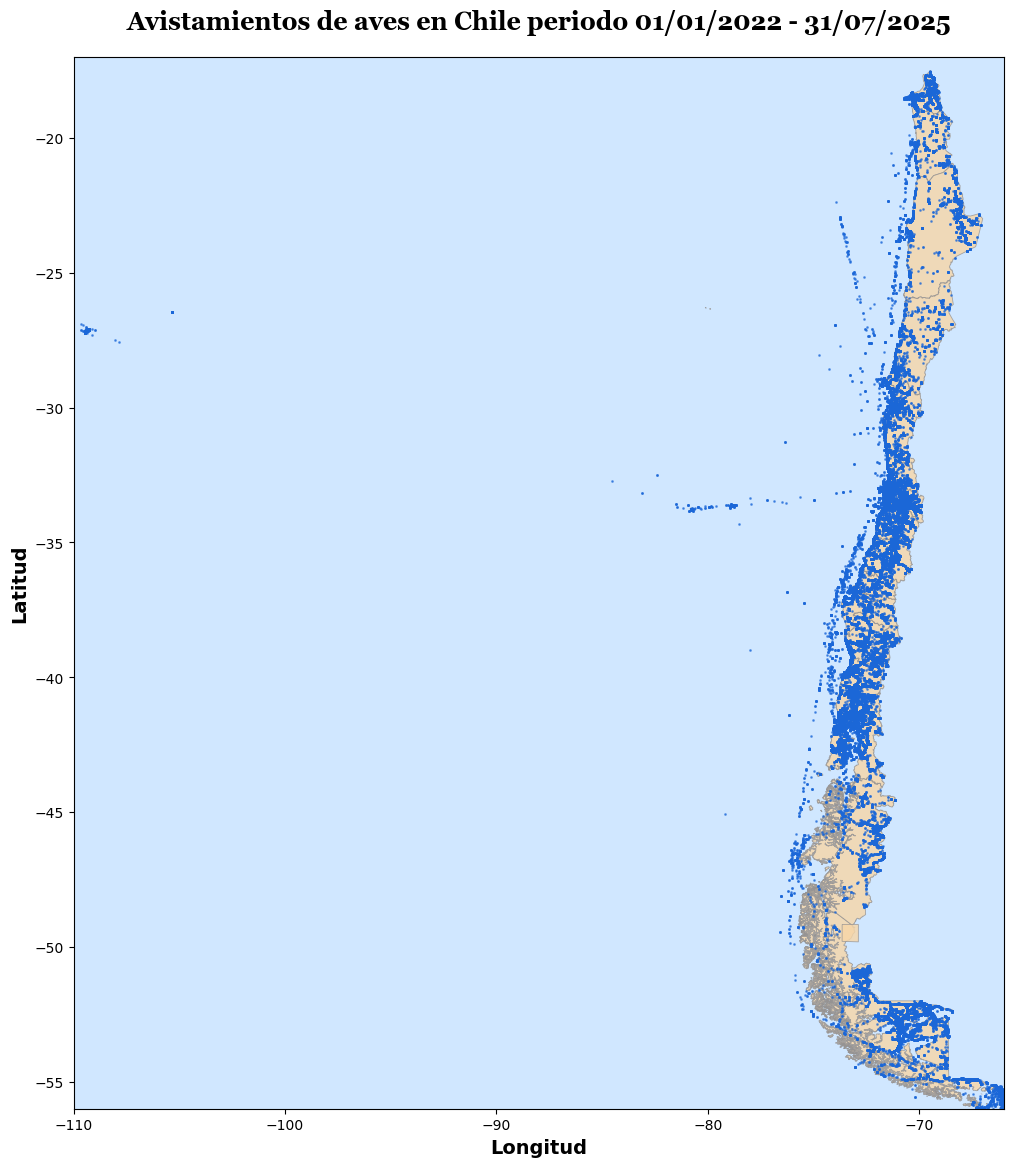

In [57]:
"""
regional_file = regional_file.to_crs("EPSG:4326")
geo_df_aves = geo_df_aves.to_crs("EPSG:4326")
"""
fig, ax = plt.subplots(figsize=(12, 16))

#Se grafican las regiones
regional_file.plot(
    ax=ax,
    color="#F7D6A7",     #Color regiones
    edgecolor="#959393", #Color bordes regionales
    linewidth=0.6,
    alpha=0.8
)

#Se grafican los avistamientos
geo_df_aves.plot(
    ax=ax,
    markersize=1,
    color="#1B67D8",    #Color de los puntos #1B67D8
    alpha=0.6
)

#Se ponen estos limites para abarcar terrotorio chileno
ax.set_xlim([-110, -66])
ax.set_ylim([-56, -17])

#Mostrar ejes y coordenadas
ax.set_axis_on()

#En este apartado se utilizó ChatGPT como asesor para poder graficar las latitudes y longitudes. 
# Prompt: "Tengo dataframe georeferenciado y un archivo con los limites regionales de chile, ambos en CRS "EPSG:4326",
# como puedo agregar al gráfico las coordenadas lat y lng.
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))  #Ticks de longitud cada 10°
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))   #Ticks de latitud cada 5°
#Fin del output del prompt.

ax.set_xlabel("Longitud", fontsize=14, fontweight='bold')
ax.set_ylabel("Latitud", fontsize=14, fontweight='bold')

#Se setea el título
ax.set_title("Avistamientos de aves en Chile periodo 01/01/2022 - 31/07/2025",fontfamily="Georgia", fontsize=18, fontweight='bold', pad=20)

# Fondo limpio
ax.set_facecolor("#D0E7FF")

plt.show()

### Síntesis 3.3 B
- Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 
- En base al mapa, es claro

### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [122]:
df_run = df[df['comName'].str.lower() == 'run-run']
df_dormilona = df[df['comName'].str.lower() == 'dormilona tontita']

if not df_run.empty and not df_dormilona.empty:
    print("DataFrames creados con éxito ✅")
else:
    print("Uno o ambos DataFrames están vacíos ⚠️")

DataFrames creados con éxito ✅


**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

In [ ]:
#Desarrollo B.
df_run = df_run.groupby("year_month", as_index=False)["howMany"].sum()
df_run.head()

,year_month,howMany
0,2022-01,75.0
1,2022-02,73.0
2,2022-03,48.0
3,2022-04,12.0
4,2022-05,1.0


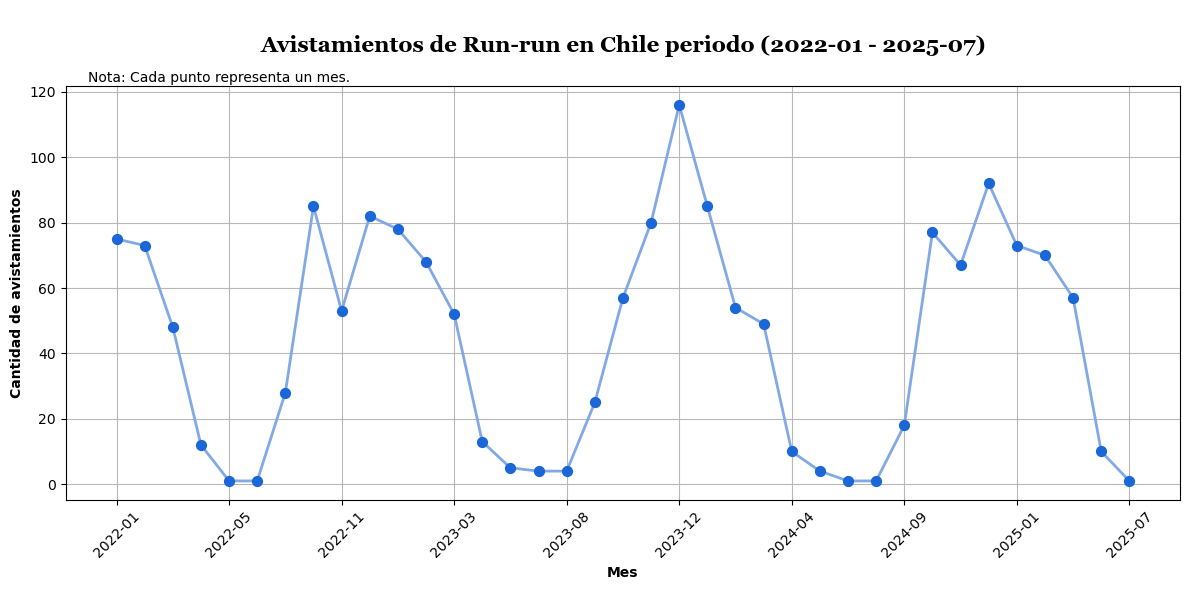

In [116]:
plt.figure(figsize=(12,6))


plt.plot(df_run["year_month"], df_run["howMany"], color="#82A9E5", linewidth=2)
plt.scatter(df_run["year_month"], df_run["howMany"], color="#1B67D8", s=50, zorder=3)


xticks = df_run["year_month"].iloc[::4]  # cada 4 pasos
plt.xticks(ticks=xticks, rotation=45)

#Titulo
plt.title("\nAvistamientos de Run-run en Chile periodo (2022-01 - 2025-07)\n", fontweight='bold', fontfamily='Georgia', fontsize=16)
plt.text(-1, 123, "Nota: Cada punto representa un mes.")

plt.xlabel("Mes", fontweight='bold')
plt.ylabel("Cantidad de avistamientos", fontweight='bold')
plt.grid(True, color="#B8B8B8")
plt.tight_layout()
plt.show()

In [123]:
df_dormilona = df_dormilona.groupby("year_month", as_index=False)['howMany'].sum()
df_dormilona.head()

,year_month,howMany
0,2022-01,31.0
1,2022-02,49.0
2,2022-03,135.0
3,2022-04,62.0
4,2022-05,165.0


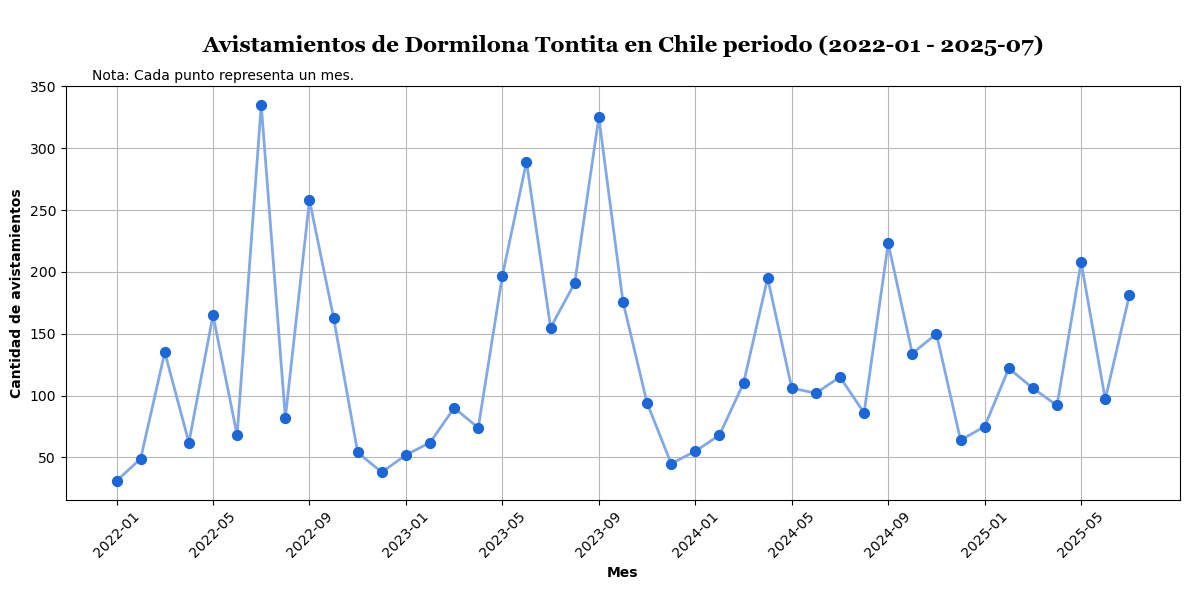

In [126]:
plt.figure(figsize=(12,6))


plt.plot(df_dormilona["year_month"], df_dormilona["howMany"], color="#82A9E5", linewidth=2)
plt.scatter(df_dormilona["year_month"], df_dormilona["howMany"], color="#1B67D8", s=50, zorder=3)


xticks = df_dormilona["year_month"].iloc[::4]  # cada 4 pasos
plt.xticks(ticks=xticks, rotation=45)

#Titulo
plt.title("\nAvistamientos de Dormilona Tontita en Chile periodo (2022-01 - 2025-07)\n", fontweight='bold', fontfamily='Georgia', fontsize=16)
plt.text(-1, 355, "Nota: Cada punto representa un mes.")

plt.xlabel("Mes", fontweight='bold')
plt.ylabel("Cantidad de avistamientos", fontweight='bold')
plt.grid(True, color="#B8B8B8")
plt.tight_layout()
plt.show()

### Sintesis 3.4 B


**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

In [ ]:
import matplotlib.colors as mcolors
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]

# Creamos un colormap cíclico para representar meses del año
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

In [ ]:
# Respuesta

**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

Respuesta